In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [12]:
df = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv')

In [13]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [14]:
print("\nDATASET SHAPE")
print(df.shape)


DATASET SHAPE
(768, 7)


In [15]:
print("\nCOLUMN NAMES\n")
print(df.columns)


COLUMN NAMES

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


**RENAME COLUMNS**

In [16]:
df.columns = [
    'Region',
    'Date',
    'Frequency',
    'Estimated_Unemployment_Rate',
    'Estimated_Employed',
    'Estimated_Labour_Participation_Rate',
    'Area'
]

In [17]:
print("\nDATASET INFORMATION")
print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               740 non-null    object 
 1   Date                                 740 non-null    object 
 2   Frequency                            740 non-null    object 
 3   Estimated_Unemployment_Rate          740 non-null    float64
 4   Estimated_Employed                   740 non-null    float64
 5   Estimated_Labour_Participation_Rate  740 non-null    float64
 6   Area                                 740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [18]:
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
Region                                 28
Date                                   28
Frequency                              28
Estimated_Unemployment_Rate            28
Estimated_Employed                     28
Estimated_Labour_Participation_Rate    28
Area                                   28
dtype: int64


**FILL MISSING VALUES USING MEAN**

In [20]:
# Fill numerical columns with mean

df['Estimated_Unemployment_Rate'] = df[
    'Estimated_Unemployment_Rate'
].fillna(
    df['Estimated_Unemployment_Rate'].mean()
)

df['Estimated_Employed'] = df[
    'Estimated_Employed'
].fillna(
    df['Estimated_Employed'].mean()
)

df['Estimated_Labour_Participation_Rate'] = df[
    'Estimated_Labour_Participation_Rate'
].fillna(
    df['Estimated_Labour_Participation_Rate'].mean()
)
print(df.isnull().sum())

Region                                 28
Date                                   28
Frequency                              28
Estimated_Unemployment_Rate             0
Estimated_Employed                      0
Estimated_Labour_Participation_Rate     0
Area                                   28
dtype: int64


In [21]:
 # FILL MISSING VALUES USING MEDIAN

df['Estimated_Unemployment_Rate'] = df[
    'Estimated_Unemployment_Rate'
].fillna(
    df['Estimated_Unemployment_Rate'].median()
)

df['Estimated_Employed'] = df[
    'Estimated_Employed'
].fillna(
    df['Estimated_Employed'].median()
)

df['Estimated_Labour_Participation_Rate'] = df[
    'Estimated_Labour_Participation_Rate'
].fillna(
    df['Estimated_Labour_Participation_Rate'].median()
)
print(df.isnull().sum())

Region                                 28
Date                                   28
Frequency                              28
Estimated_Unemployment_Rate             0
Estimated_Employed                      0
Estimated_Labour_Participation_Rate     0
Area                                   28
dtype: int64


In [22]:
# Fill categorical columns using mode

df['Region'] = df['Region'].fillna(
    df['Region'].mode()[0]
)

df['Date'] = df['Date'].fillna(
    df['Date'].mode()[0]
)

df['Frequency'] = df['Frequency'].fillna(
    df['Frequency'].mode()[0]
)

df['Area'] = df['Area'].fillna(
    df['Area'].mode()[0]
)

# Check missing values again
print(df.isnull().sum())

Region                                 0
Date                                   0
Frequency                              0
Estimated_Unemployment_Rate            0
Estimated_Employed                     0
Estimated_Labour_Participation_Rate    0
Area                                   0
dtype: int64


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_57/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
df['Month'] = df['Date'].dt.month

print(df[['Date', 'Month']].head())

        Date  Month
0 2019-05-31      5
1 2019-06-30      6
2 2019-07-31      7
3 2019-08-31      8
4 2019-09-30      9


In [25]:
df['Year'] = df['Date'].dt.year

print(df[['Date', 'Year']].head())

        Date  Year
0 2019-05-31  2019
1 2019-06-30  2019
2 2019-07-31  2019
3 2019-08-31  2019
4 2019-09-30  2019


**Unemployment Trend Line Graph**

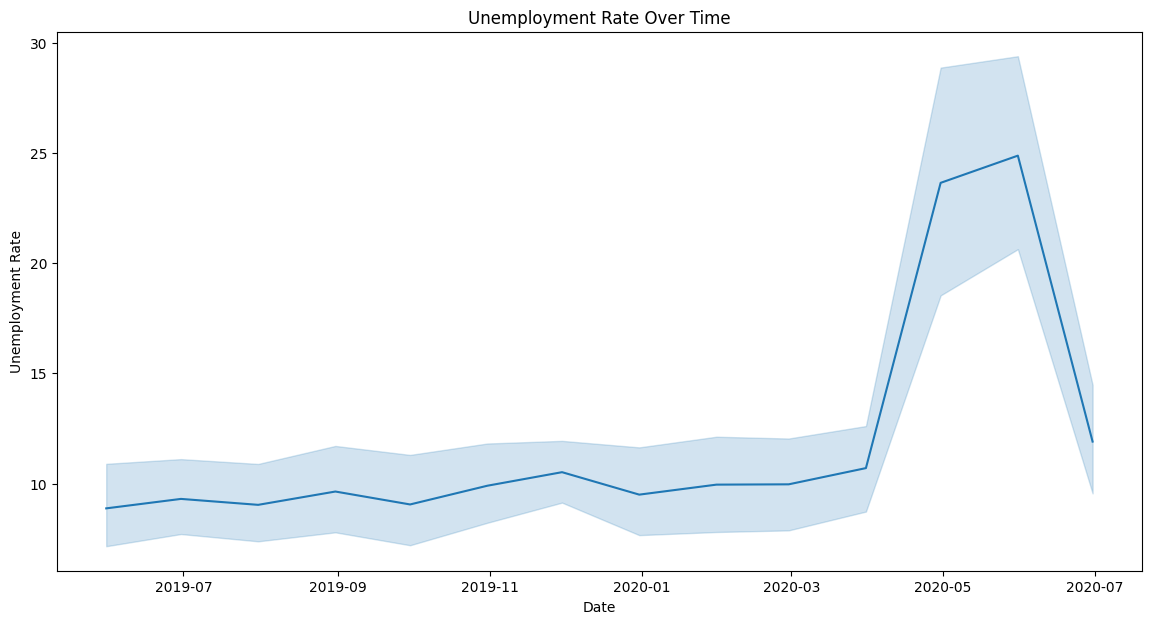

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.lineplot(
    x='Date',
    y='Estimated_Unemployment_Rate',
    data=df
)

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate")

plt.show()

**Histogram**

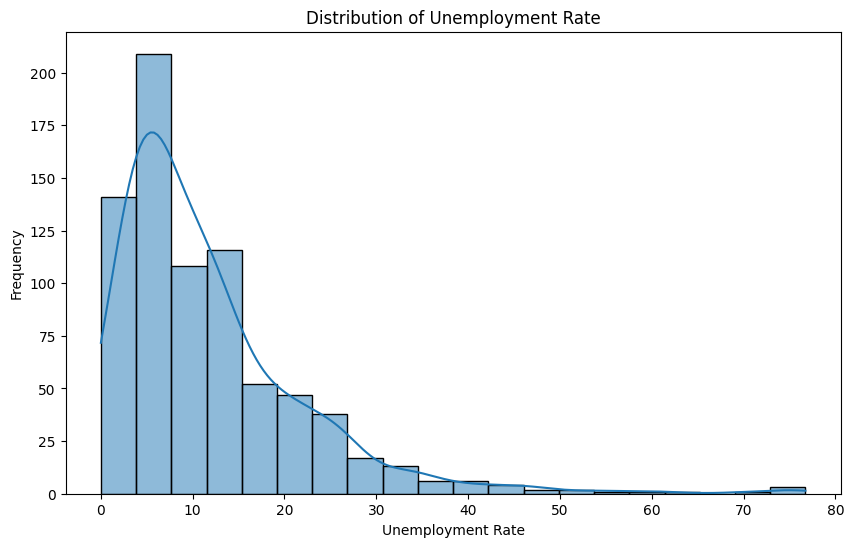

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated_Unemployment_Rate'],
    kde=True,
    bins=20
)

plt.title("Distribution of Unemployment Rate")

plt.xlabel("Unemployment Rate")

plt.ylabel("Frequency")

plt.show()

**Bar Plot**

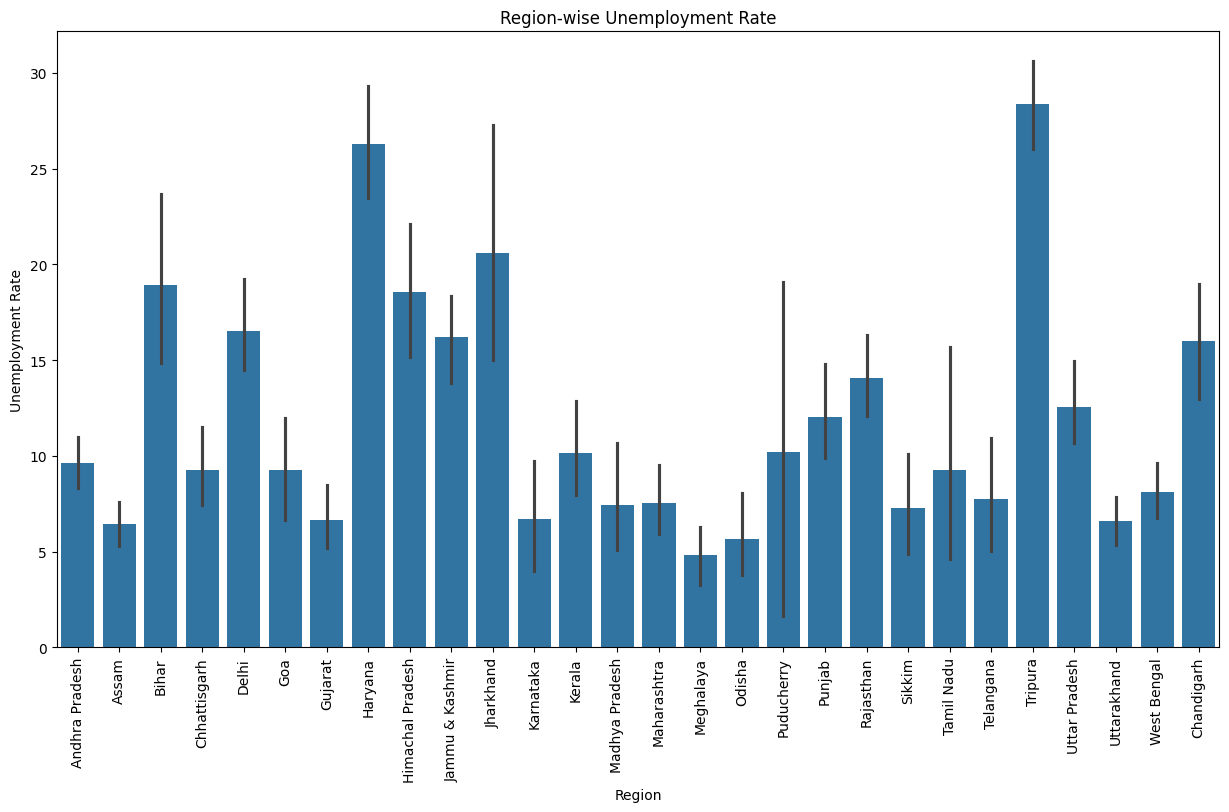

In [31]:
plt.figure(figsize=(15,8))

sns.barplot(
    x='Region',
    y='Estimated_Unemployment_Rate',
    data=df
)

plt.xticks(rotation=90)

plt.title("Region-wise Unemployment Rate")

plt.xlabel("Region")

plt.ylabel("Unemployment Rate")

plt.show()

**Correlation Heatmap**

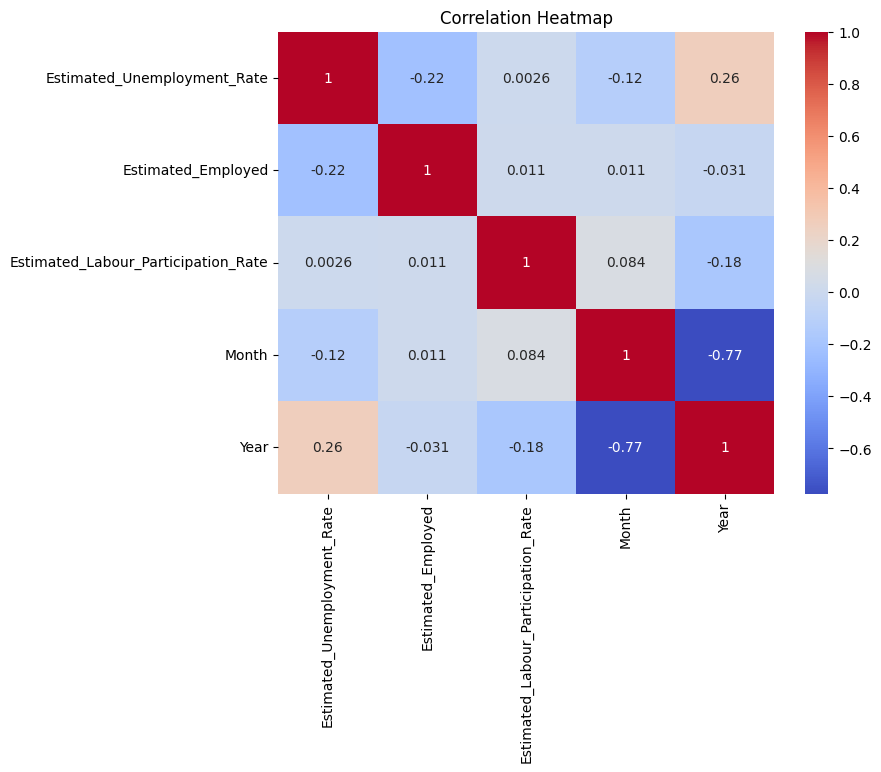

In [32]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Boxplot**

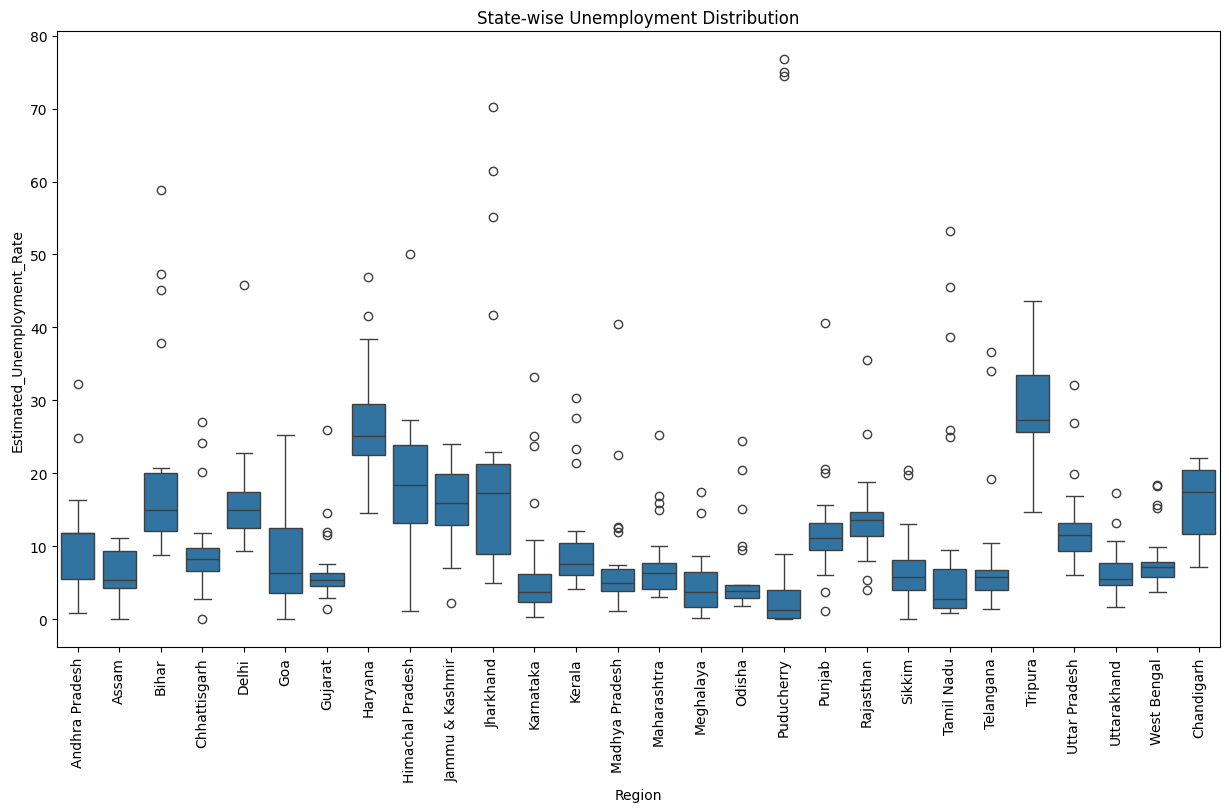

In [33]:
plt.figure(figsize=(15,8))

sns.boxplot(
    x='Region',
    y='Estimated_Unemployment_Rate',
    data=df
)

plt.xticks(rotation=90)

plt.title("State-wise Unemployment Distribution")

plt.show()

**Scatter Plot**

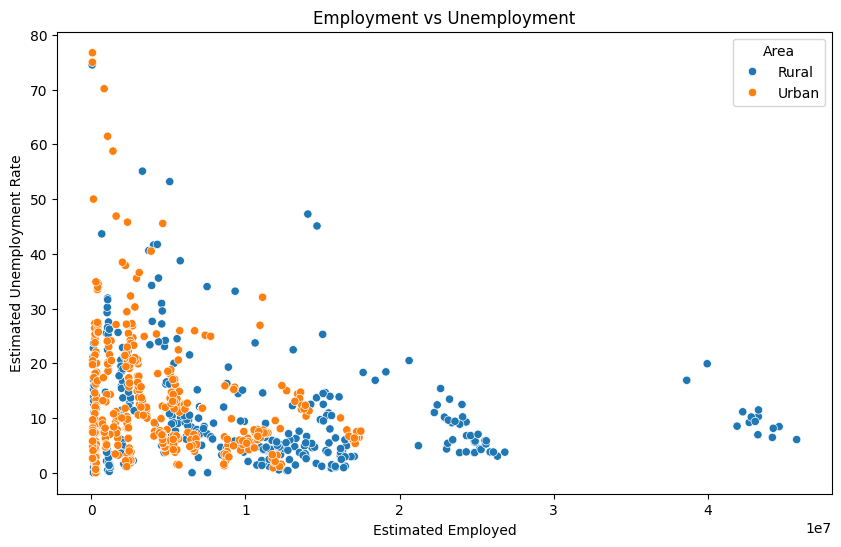

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Estimated_Employed',
    y='Estimated_Unemployment_Rate',
    hue='Area',
    data=df
)

plt.title("Employment vs Unemployment")

plt.xlabel("Estimated Employed")

plt.ylabel("Estimated Unemployment Rate")

plt.show()

**Monthly Trend Graph**

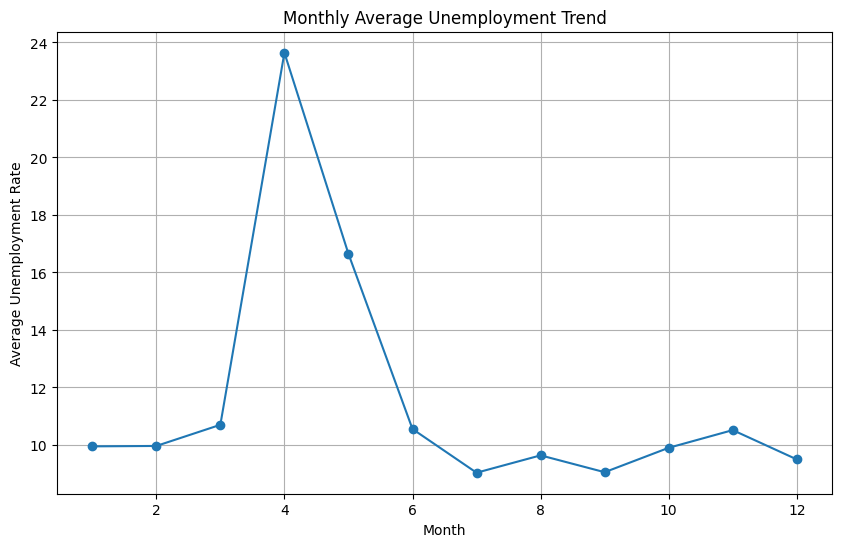

In [35]:
monthly_avg = df.groupby('Month')[
    'Estimated_Unemployment_Rate'
].mean()

plt.figure(figsize=(10,6))

monthly_avg.plot(marker='o')

plt.title("Monthly Average Unemployment Trend")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate")

plt.grid()

plt.show()

**Top 10 Regions Graph**

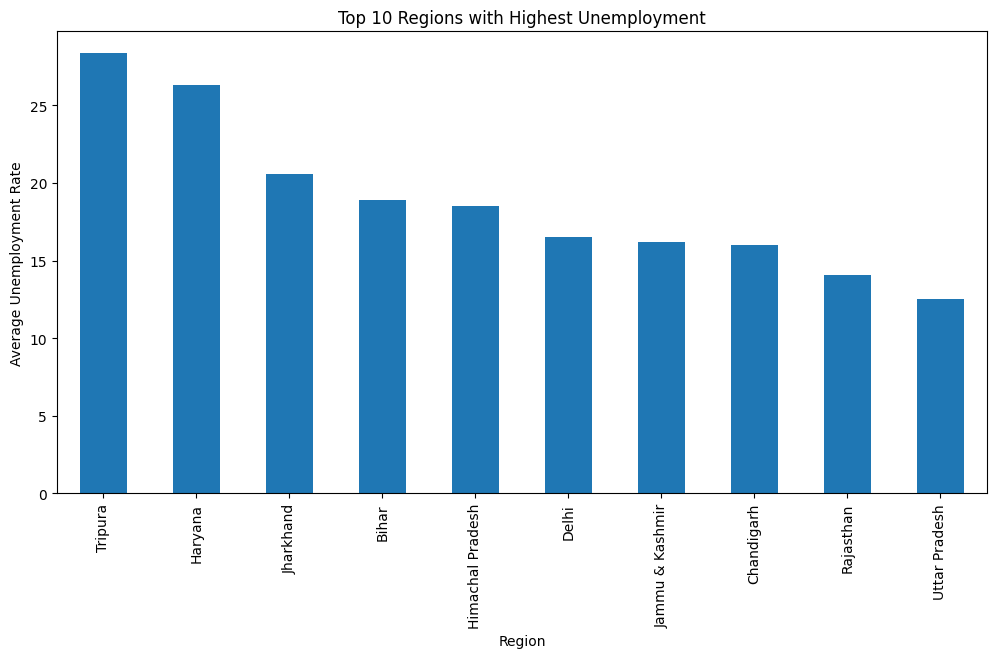

In [36]:
top_regions = df.groupby('Region')[
    'Estimated_Unemployment_Rate'
].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_regions.plot(kind='bar')

plt.title("Top 10 Regions with Highest Unemployment")

plt.xlabel("Region")

plt.ylabel("Average Unemployment Rate")

plt.show()

**Covid-19 Impact Graph**

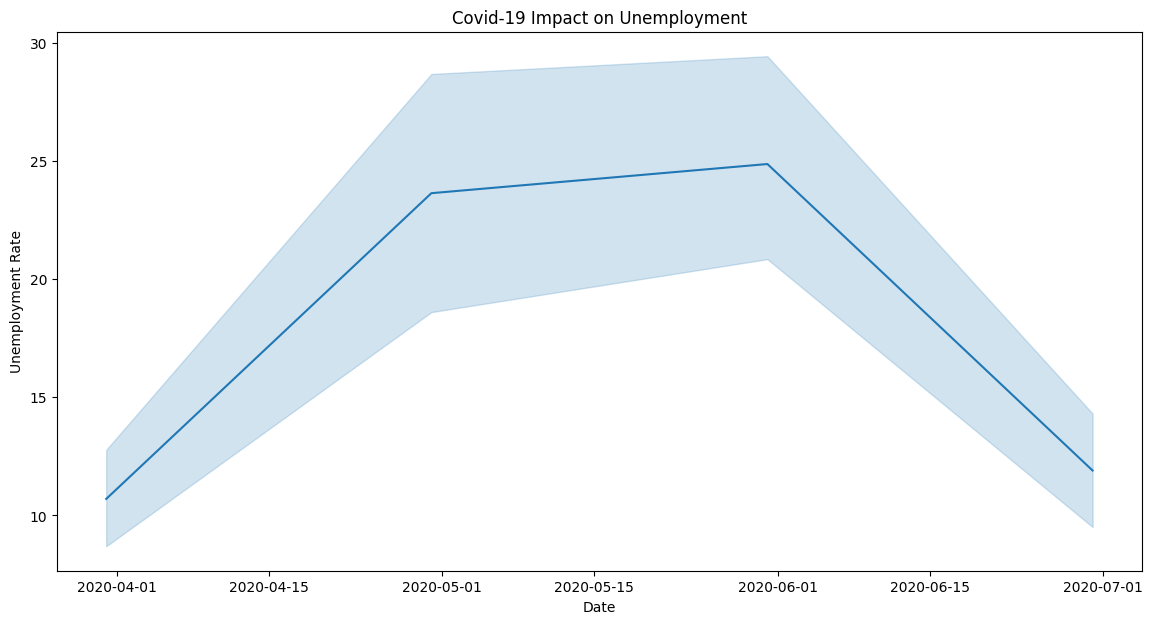

In [37]:
covid_data = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-12-31')
]

plt.figure(figsize=(14,7))

sns.lineplot(
    x='Date',
    y='Estimated_Unemployment_Rate',
    data=covid_data
)

plt.title("Covid-19 Impact on Unemployment")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate")

plt.show()

**Pie Chart**

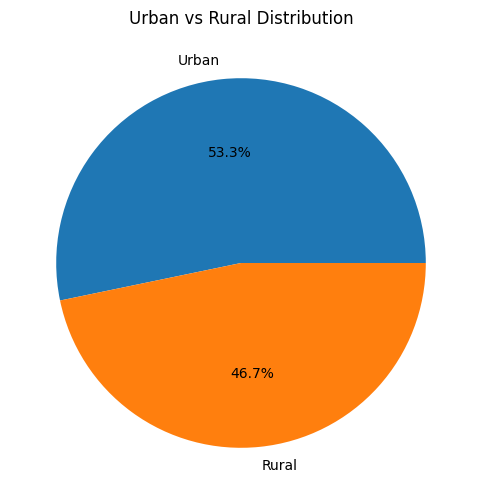

In [38]:
area_count = df['Area'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    area_count,
    labels=area_count.index,
    autopct='%1.1f%%'
)

plt.title("Urban vs Rural Distribution")

plt.show()

**Pairplot**

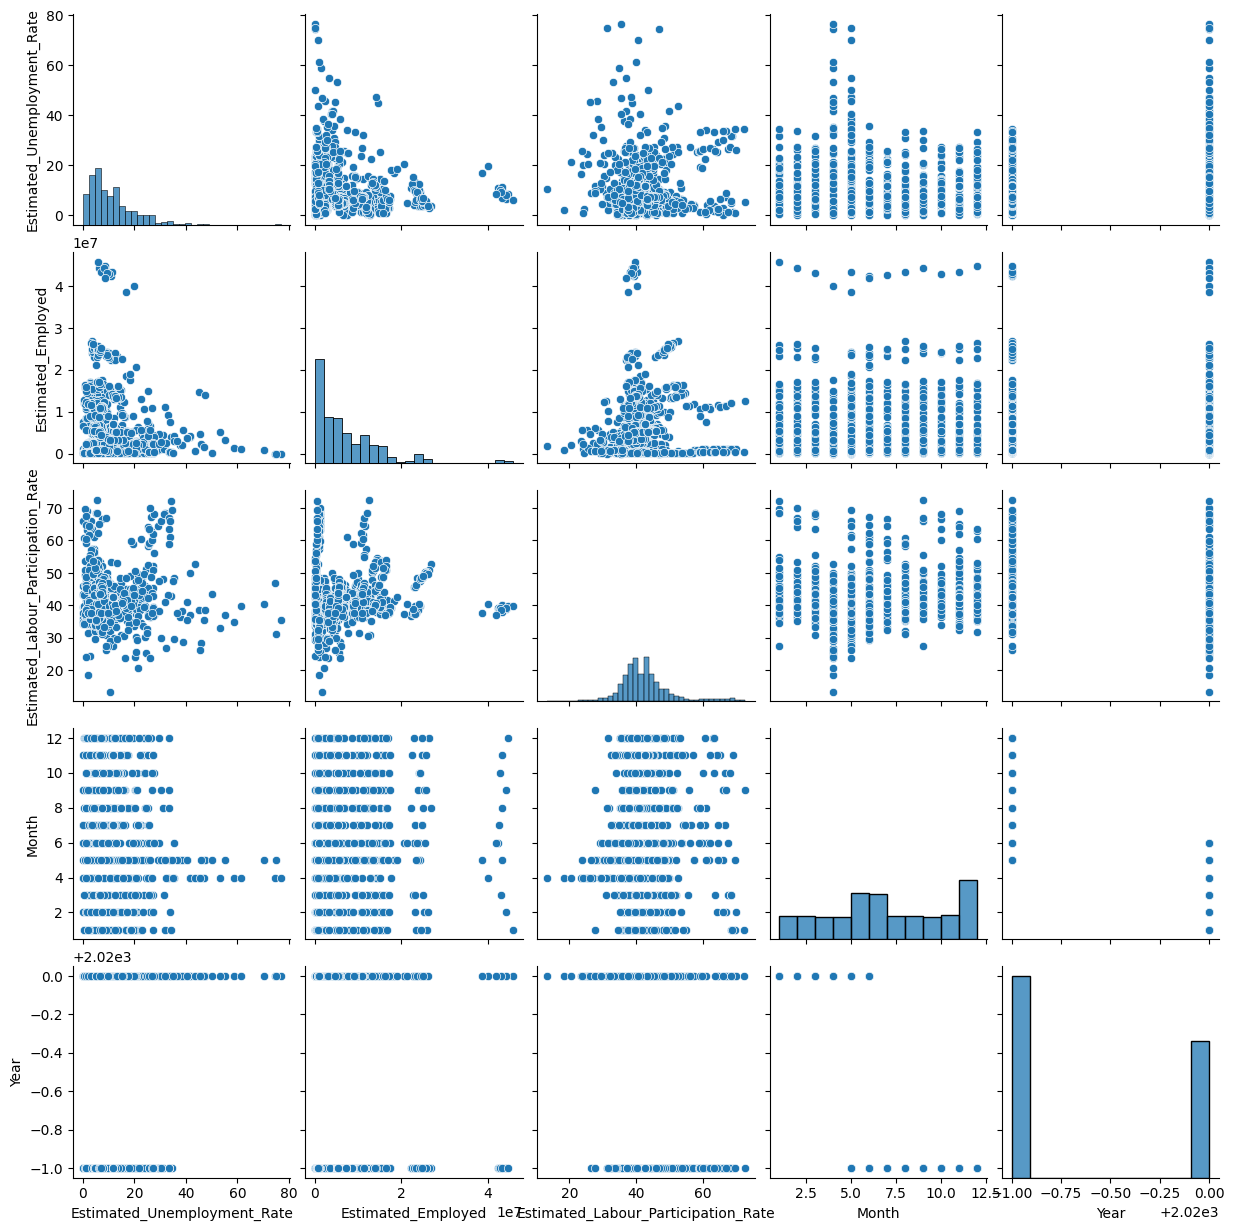

In [39]:
sns.pairplot(
    numeric_df
)

plt.show()

* **Insights & Conclusions Section** 

**Average Unemployment Rate**

In [40]:
average_rate = df[
    'Estimated_Unemployment_Rate'
].mean()

print("Average Unemployment Rate:")
print(round(average_rate, 2))

Average Unemployment Rate:
11.79


**Highest Unemployment Region**

In [41]:
highest_region = df.groupby('Region')[
    'Estimated_Unemployment_Rate'
].mean().sort_values(
    ascending=False
).head(1)

print("Region with Highest Unemployment:")
print(highest_region)

Region with Highest Unemployment:
Region
Tripura    28.350357
Name: Estimated_Unemployment_Rate, dtype: float64


**Lowest Unemployment Region**

In [42]:
lowest_region = df.groupby('Region')[
    'Estimated_Unemployment_Rate'
].mean().sort_values(
    ascending=True
).head(1)

print("Region with Lowest Unemployment:")
print(lowest_region)

Region with Lowest Unemployment:
Region
Meghalaya    4.798889
Name: Estimated_Unemployment_Rate, dtype: float64


**Covid-19 Impact Analysis**

In [43]:
covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-12-31')
]

covid_avg = covid_period[
    'Estimated_Unemployment_Rate'
].mean()

print("Average Unemployment During Covid:")
print(round(covid_avg, 2))

Average Unemployment During Covid:
17.77


**Rural vs Urban Analysis**

In [44]:
area_analysis = df.groupby('Area')[
    'Estimated_Unemployment_Rate'
].mean()

print(area_analysis)

Area
Rural    10.324791
Urban    13.072231
Name: Estimated_Unemployment_Rate, dtype: float64


**Monthly Trend Analysis**

In [45]:
monthly_avg = df.groupby('Month')[
    'Estimated_Unemployment_Rate'
].mean()

print(monthly_avg)

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11    10.515934
12     9.497358
Name: Estimated_Unemployment_Rate, dtype: float64


**Correlation Analysis**

In [46]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                                     Estimated_Unemployment_Rate  \
Estimated_Unemployment_Rate                             1.000000   
Estimated_Employed                                     -0.222876   
Estimated_Labour_Participation_Rate                     0.002558   
Month                                                  -0.118620   
Year                                                    0.259217   

                                     Estimated_Employed  \
Estimated_Unemployment_Rate                   -0.222876   
Estimated_Employed                             1.000000   
Estimated_Labour_Participation_Rate            0.011300   
Month                                          0.010889   
Year                                          -0.031431   

                                     Estimated_Labour_Participation_Rate  \
Estimated_Unemployment_Rate                                     0.002558   
Estimated_Employed                                              0.011300   
Estimate

================ PROJECT INSIGHTS ================

1. Covid-19 significantly increased unemployment rates.

2. Some regions experienced much higher unemployment
   compared to others.

3. Urban and rural unemployment patterns differ.

4. Monthly unemployment trends indicate seasonal
   economic fluctuations.

5. Labour participation rate has relationship with
   unemployment levels.

6. Economic lockdowns during Covid-19 caused major
   employment disruption.

7. Data visualization helped identify hidden trends
   and patterns effectively.

==================================================

PROJECT CONCLUSION

This project analyzed unemployment trends using Python.

Key tasks performed:
- Data Cleaning
- Missing Value Handling
- Data Visualization
- Trend Analysis
- Covid-19 Impact Analysis

The analysis showed that unemployment increased
significantly during the Covid-19 period.

Regional and seasonal unemployment differences
were also identified successfully.

This project demonstrates how data science can
help understand economic and social conditions.